### Guardrail #8 (Tool Authorization) and Guardrail #9 / #10 (Risk Classification & Human-in-the-loop).

In [1]:
from typing import TypedDict, Optional, Literal
from langgraph.graph import StateGraph, START,END
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import InMemorySaver



In [2]:
# ==========================================
# 1. POLICIES (Deterministic Guardrails)
# ==========================================
# Guardrail #8: Role-Based Access Control (RBAC)
ROLE_PERMISSIONS = {
    "guest": ["search_records"],
    "admin": ["search_records", "delete_database"]
}

# Guardrail #9: Risk Classification
TOOL_RISK = {
    "search_records": "LOW",
    "delete_database": "HIGH"
}

In [3]:
# ==========================================
# 2. STATE
# ==========================================
class AgentState(TypedDict):
    user_role: str
    requested_tool: Optional[str]
    tool_status: Optional[str] # 'checking', 'denied', 'approved', 'rejected_by_human', 'executed'
    final_response: Optional[str]

In [4]:
def agent_node(state:AgentState):
    """Mocks an LLM deciding to use a destructive tool."""
    print("\n[Agent] Thinking... I will try to use 'delete_database'.")

    # The LLM adapts based on the guardrail's feedback
    if state["tool_status"]=="denied":
        print("[Agent] I hit an RBAC permission error. I'll stop.")
        return {"final_response": "I cannot perform this action. Permission denied."}
    
    if state.get("tool_status") == "rejected_by_human":
        print("[Agent] The admin rejected my request. I'll tell the user.")
        return {"final_response": "Action was aborted by human supervisor."}
    
    if state.get("tool_status") == "executed":
        print("[Agent] The tool worked! I will summarize.")
        return {"final_response": "Success: The database has been deleted."}

    # First attempt: request the tool
    return {"requested_tool": "delete_database", "tool_status": "checking"}

def guardrail_node(state: AgentState):
    """Guardrails #8 and #9: Authorization and Risk Assessment."""
    tool = state["requested_tool"]
    role = state["user_role"]
    
    print(f"--- [Guardrail] Checking access for role '{role}' on '{tool}' ---")
    
    # 1. Authorization Guard
    if tool not in ROLE_PERMISSIONS.get(role, []):
        print("GUARD_FAIL: Unauthorized Access.")
        return {"tool_status": "denied"}
        
    # 2. Risk & Human-in-the-Loop Guard
    if TOOL_RISK.get(tool) == "HIGH":
        print("GUARD_WARN: High-Risk Action. Pausing graph for human review...")
        
        # This pauses the entire application and saves state to the Checkpointer
        human_decision = interrupt(f"Require human approval for: {tool}")
        
        if human_decision == "approve":
            print("HUMAN APPROVED.")
            return {"tool_status": "approved"}
        else:
            print("HUMAN REJECTED.")
            return {"tool_status": "rejected_by_human"}

    print("GUARD_PASS: Low risk, auto-approved.")
    return {"tool_status": "approved"}

def execute_tool_node(state: AgentState):
    """Executes the tool (Only reachable if passed all guards)."""
    print(f"--- [Execution] Running {state['requested_tool']} ---")
    return {"tool_status": "executed"}



In [5]:
# ==========================================
# 4. ORCHESTRATION & ROUTING
# ==========================================
def route_after_guard(state: AgentState) -> Literal["execute_tool_node", "agent_node"]:
    if state["tool_status"] == "approved":
        return "execute_tool_node"
    return "agent_node" # Route back to LLM to handle the denial/rejection

def route_after_agent(state: AgentState) -> Literal["guardrail_node", "END"]:
    if state.get("final_response"): return "END"
    return "guardrail_node"

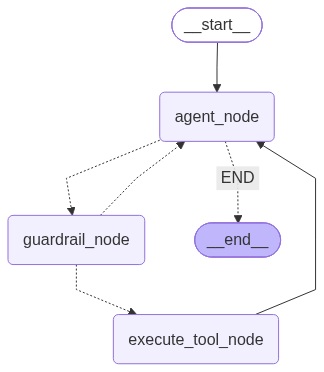

In [6]:
workflow = StateGraph(AgentState)
workflow.add_node("agent_node", agent_node)
workflow.add_node("guardrail_node", guardrail_node)
workflow.add_node("execute_tool_node", execute_tool_node)

workflow.add_edge(START, "agent_node")
workflow.add_conditional_edges("agent_node", route_after_agent,
                                {"END":END,
                                "guardrail_node":"guardrail_node"})
workflow.add_conditional_edges("guardrail_node", route_after_guard)
workflow.add_edge("execute_tool_node", "agent_node")

# A Checkpointer is MANDATORY for interrupt() to save the paused state
checkpointer = InMemorySaver()
app = workflow.compile(checkpointer=checkpointer)
app

In [8]:
# ==========================================
# 5. EXECUTION TESTS
# ==========================================
print("\n=== SCENARIO 1: A GUEST TRIES TO DELETE ===")
config = {"configurable": {"thread_id": "guest_thread"}}
app.invoke({"user_role": "guest","tool_status": None}, config=config)


=== SCENARIO 1: A GUEST TRIES TO DELETE ===

[Agent] Thinking... I will try to use 'delete_database'.
--- [Guardrail] Checking access for role 'guest' on 'delete_database' ---
GUARD_FAIL: Unauthorized Access.

[Agent] Thinking... I will try to use 'delete_database'.
[Agent] I hit an RBAC permission error. I'll stop.


{'user_role': 'guest',
 'requested_tool': 'delete_database',
 'tool_status': 'denied',
 'final_response': 'I cannot perform this action. Permission denied.'}

In [9]:
print("\n=== SCENARIO 2: AN ADMIN TRIES TO DELETE (Requires Human) ===")
config_admin = {"configurable": {"thread_id": "admin_thread"}}

# Step A: Run until the interrupt pauses it
app.invoke({"user_role": "admin","tool_status": None}, config=config_admin)


=== SCENARIO 2: AN ADMIN TRIES TO DELETE (Requires Human) ===

[Agent] Thinking... I will try to use 'delete_database'.
--- [Guardrail] Checking access for role 'admin' on 'delete_database' ---
GUARD_WARN: High-Risk Action. Pausing graph for human review...


{'user_role': 'admin',
 'requested_tool': 'delete_database',
 'tool_status': 'checking',
 '__interrupt__': [Interrupt(value='Require human approval for: delete_database', id='b1e37fa31b7d6cd81898b8a90f1ea22c')]}

In [10]:
# Step B: The Human clicks "Approve" (Resumes the paused graph)
app.invoke(Command(resume="approve"), config=config_admin)

--- [Guardrail] Checking access for role 'admin' on 'delete_database' ---
GUARD_WARN: High-Risk Action. Pausing graph for human review...
HUMAN APPROVED.
--- [Execution] Running delete_database ---

[Agent] Thinking... I will try to use 'delete_database'.
[Agent] The tool worked! I will summarize.


{'user_role': 'admin',
 'requested_tool': 'delete_database',
 'tool_status': 'executed',
 'final_response': 'Success: The database has been deleted.'}

#### When building this for production, a few things change:

    Authentication Identity: The user_role must come from a secure JWT (JSON Web Token) or API Gateway middleware—never from a user's prompt or the LangGraph input message.

    Asynchronous Checkpoints: The MemorySaver becomes an AsyncPostgresSaver. When the graph hits interrupt(), the Python process actually dies/exits to save server costs. When the human clicks "Approve" via your API three days later, LangGraph pulls the state back out of Postgres and perfectly resumes execution.

    Feedback Loops: Notice how our router sends denied or rejected_by_human back to the agent_node rather than just crashing? This allows the LLM to gracefully apologize to the user: "I'm sorry, my supervisor denied the request to delete that file."